# Analysis of Monthly Returns and Volatility of NIFTY 100 Constituents

Ravi Kumar

Roll No: 23/EC/164

Delhi Technological University

## Objective

To analyze the monthly returns and volatility of NIFTY 100 constituent companies using historical stock price data obtained from Yahoo Finance. The constituent list was dynamically extracted and validated, resulting in 100 companies being included in the final analysis.

## Load Dataset

In [1]:
import pandas as pd

url = "https://archives.nseindia.com/content/indices/ind_nifty100list.csv"

nifty100 = pd.read_csv(url)

print("Latest NIFTY 100 Constituents Loaded")
print("Companies:", len(nifty100))

nifty100.head()

Latest NIFTY 100 Constituents Loaded
Companies: 104


,Company Name,Industry,Symbol,Series,ISIN Code
0,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022
1,Adani Energy Solutions Ltd.,Power,ADANIENSOL,EQ,INE931S01010
2,Adani Enterprises Ltd.,Metals & Mining,ADANIENT,EQ,INE423A01024
3,Adani Green Energy Ltd.,Power,ADANIGREEN,EQ,INE364U01010
4,Adani Ports and Special Economic Zone Ltd.,Services,ADANIPORTS,EQ,INE742F01042


104 constituents were extracted from NSE data. After validation through Yahoo Finance, 100 valid companies were used for analysis.

## Loading NIFTY 100 Constituent Companies

In [2]:
stocks = nifty100["Symbol"].tolist()

stocks = list(dict.fromkeys(stocks))

print("Extracted Constituents:", len(stocks))

Extracted Constituents: 104


## Downloading Historical Stock Price Data

In [3]:
import yfinance as yf
import logging

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

all_tickers = [s + ".NS" for s in stocks]

valid_tickers = []

for ticker in all_tickers:
    try:
        temp = yf.download(
    ticker,
    period="5d",
    auto_adjust=True,
    progress=False
)

        if not temp.empty:
            valid_tickers.append(ticker)

    except:
        pass

print("Final Valid Tickers:", len(valid_tickers))

data = yf.download(
    valid_tickers,
    start="2023-01-01",
    end="2026-01-01",
    auto_adjust=True,
    group_by="ticker",
    progress=True
)

print("Download Complete")

[                       0%                       ]

Final Valid Tickers: 100


[*********************100%***********************]  100 of 100 completed

Download Complete


In [4]:
print("Final Dataset Stocks:", len(valid_tickers))
print(valid_tickers[:10])

Final Dataset Stocks: 100
['ABB.NS', 'ADANIENSOL.NS', 'ADANIENT.NS', 'ADANIGREEN.NS', 'ADANIPORTS.NS', 'ADANIPOWER.NS', 'AMBUJACEM.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'DMART.NS']


## Monthly Return Calculation

In [5]:
monthly_returns = pd.DataFrame()

for ticker in valid_tickers:
    try:
        close = data[ticker]["Close"]

        monthly_close = close.resample("ME").last()

        monthly_return = monthly_close.pct_change() * 100

        monthly_returns[ticker] = monthly_return

    except:
        pass

monthly_returns.head()

,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,DMART.NS,...,TITAN.NS,TORNTPHARM.NS,TRENT.NS,ULTRACEMCO.NS,UNIONBANK.NS,UNITDSPR.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-28,13.306911,-63.759863,-54.139339,-60.348069,-3.297149,-34.629130,-14.730800,3.564364,3.776796,-2.436973,...,-0.182992,-3.188173,6.815143,2.480403,-14.331215,-3.649264,13.478728,-16.060750,-2.958496,7.936502
2023-03-31,4.593837,54.464139,28.346231,81.568112,6.658794,30.963771,6.854708,-2.061736,-2.373797,-0.465324,...,5.988708,5.295062,7.573429,4.969502,-1.040890,2.119905,6.630789,2.273158,-5.632347,5.528124
2023-04-30,1.733588,3.665471,9.968852,7.927138,7.817684,17.353866,8.466702,4.704363,5.094781,3.260755,...,5.047920,7.491129,-0.523656,-0.865238,13.974450,2.756856,4.268601,9.637118,5.407258,5.767476
2023-05-31,20.712715,-24.551940,29.528053,2.807572,8.447086,11.029573,6.834808,2.398254,10.012581,-1.158899,...,6.866395,11.105728,14.200621,4.153536,-6.262369,13.684601,17.246764,6.163228,4.844154,-3.385270


## Average Monthly Return and Volatility Analysis

In [6]:
summary = pd.DataFrame()

summary["Average Monthly Return (%)"] = monthly_returns.mean()
summary["Volatility (%)"] = monthly_returns.std()

summary = summary.dropna()

summary = summary.sort_values(
    by="Average Monthly Return (%)",
    ascending=False
)

summary.head()

,Average Monthly Return (%),Volatility (%)
MAZDOCK.NS,6.846906,18.155181
ETERNAL.NS,5.509802,9.912943
IRFC.NS,5.487069,19.424165
BEL.NS,4.720620,9.683043
SHRIRAMFIN.NS,4.556606,9.883002


## Top 10 Performing Stocks


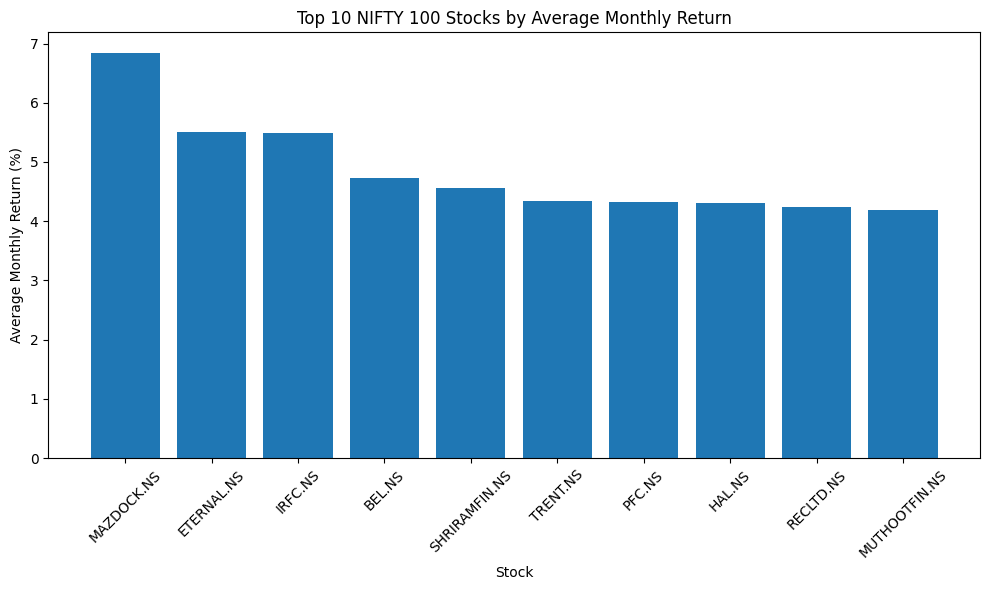

In [7]:
import matplotlib.pyplot as plt

top10 = summary.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10.index,
    top10["Average Monthly Return (%)"]
)

plt.title("Top 10 NIFTY 100 Stocks by Average Monthly Return")
plt.xlabel("Stock")
plt.ylabel("Average Monthly Return (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Top 10 Most Volatile Stocks

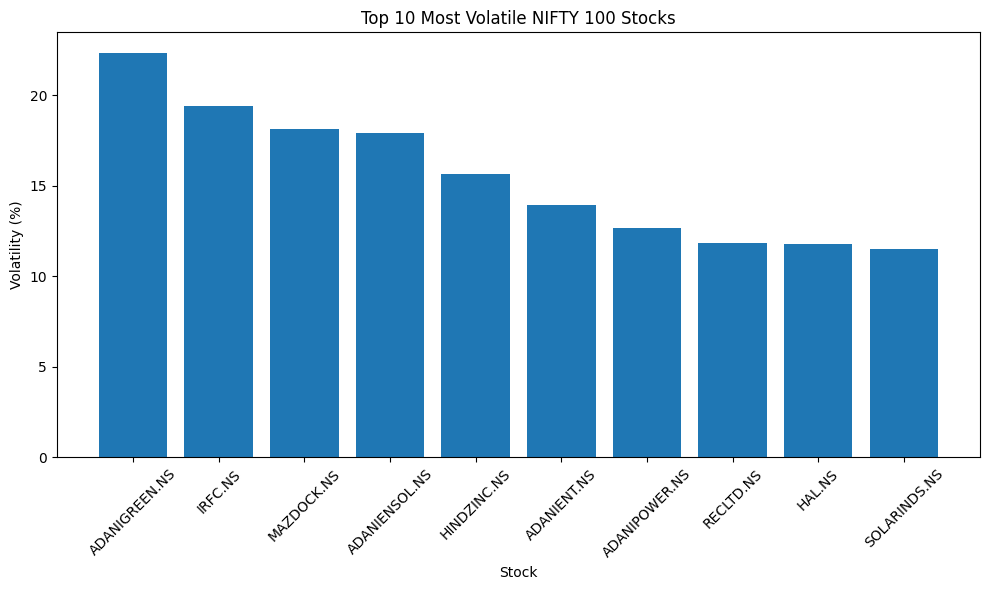

In [8]:
volatility_top10 = summary.sort_values(
    by="Volatility (%)",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    volatility_top10.index,
    volatility_top10["Volatility (%)"]
)

plt.title("Top 10 Most Volatile NIFTY 100 Stocks")
plt.xlabel("Stock")
plt.ylabel("Volatility (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Exporting Results

In [9]:
summary.to_csv("nifty100_stock_analysis.csv")

monthly_returns.to_csv(
    "nifty100_monthly_returns_all_stocks.csv"
)

print("Files Exported Successfully")

Files Exported Successfully


## Limitation

Out of 104 extracted constituents, 100 valid companies were successfully analyzed. Four symbols were excluded because historical price data was unavailable through Yahoo Finance at the time of extraction.

## Conclusion

The monthly returns and volatility of NIFTY 100 constituent companies were analyzed using historical stock price data from January 2023 to December 2025.

##Key Findings

• 104 constituent symbols were extracted from NSE data.
• 100 companies contained valid historical price data and were included in the final analysis.
• Average monthly return and volatility were calculated for each company.
• Mazdock, Eternal and IRFC were among the strongest performers during the study period.
• Adani Green and IRFC exhibited comparatively higher volatility.
• The analysis highlights the risk-return characteristics of major Indian equities.

## Tools Used
• Python
• Pandas
• Matplotlib
• yFinance
• Google Colab markets.

